In [1]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
from scipy.stats import norm
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist

In [2]:
# load
X =np.load('data/f4/updated_inputs.npy')
y=np.load('data/f4/updated_outputs.npy')

In [3]:
# Data Normalization
y_mean_val = np.mean(y)
y_std_val  = np.std(y)
y_norm    = (y - y_mean_val) / y_std_val if y_std_val > 0 else y# Normalization
y_mean_val = np.mean(y)
y_std_val  = np.std(y)
y_norm    = (y - y_mean_val) / y_std_val if y_std_val > 0 else y

In [4]:
# The best
best_f = np.max(y_norm)
best_idx = np.argmax(y_norm)
print(f"Best current result: X = {X[best_idx]}, y_norm = {best_f:.4f}")

Best current result: X = [0.483343 0.342411 0.320498 0.440285], y_norm = 2.0668


In [5]:
# Compute distance for RBF lengthscale
distances = pdist(X, metric='euclidean') # compute mean distance between data

In [6]:
# Grid for prediction
from scipy.stats import qmc

dim=4
n_grid = 5000 
sampler = qmc.LatinHypercube(d=dim, seed=42)
sample = sampler.random(n=n_grid)

# Define bounds
l_bounds = X.min(axis=0)  
u_bounds = X.max(axis=0)  
x_grid_d = qmc.scale(sample, l_bounds, u_bounds)

In [7]:
###  New adquisition Function EI (same GP)

In [8]:
# EI
def expected_improvement(mean, std, best_f, xi=0.01):
    Z  = (mean - best_f - xi) / (std + 1e-9)
    ei = (mean - best_f - xi) * norm.cdf(Z) + std * norm.pdf(Z)
    ei[std <= 0.0] = 0.0
    return ei

In [9]:
# GP model: find optimal alpha
noise_assumption = 1e-6
Alpha=[]
Mean=[]
STD=[]
for alpha in np.linspace(0.1, 3, 30):
    rbf_lengthscale  = alpha*distances.mean()#1.5 times mean distance
    # print('lenght_scale=', rbf_lengthscale)
    kernel = RBF(length_scale=rbf_lengthscale, length_scale_bounds='fixed')
    model  = GaussianProcessRegressor(kernel=kernel, alpha=noise_assumption)
    model.fit(X, y_norm)
    # GP prediction ---
    post_mean, post_std = model.predict(x_grid_d, return_std=True)  
    ei_values = expected_improvement(post_mean, post_std, best_f, xi=0.01)
    # Find best for current alpha
    idx_next  = np.argmax(ei_values)# simple grid
    x_next    = x_grid_d[idx_next]
    Alpha.append(alpha)
    Mean.append(post_mean[idx_next])
    STD.append(post_std[idx_next])

In [10]:
###  New adquisition Function EI (same GP)

Alpha for max mean= 0.5


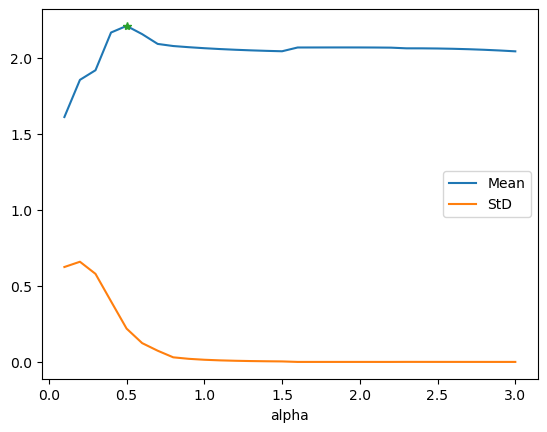

In [11]:
# Identify optimal alpha

id_max = np.argmax(Mean)
plt.plot(Alpha,Mean, label='Mean')
plt.plot(Alpha,STD, label='StD')
plt.plot(Alpha[id_max], Mean[id_max], marker='*')
plt.xlabel('alpha')
plt.legend()

print('Alpha for max mean=',Alpha[id_max])

In [12]:
# re-compute maximum for best alpha
alpha=Alpha[id_max]
rbf_lengthscale  = alpha*distances.mean()#max mean distance
kernel = RBF(length_scale=rbf_lengthscale, length_scale_bounds='fixed')
model  = GaussianProcessRegressor(kernel=kernel, alpha=noise_assumption)
model.fit(X, y_norm)
# GP prediction ---
post_mean, post_std = model.predict(x_grid_d, return_std=True)
ei_values = expected_improvement(post_mean, post_std, best_f, xi=0.01)

In [13]:
# The next point
idx_next  = np.argmax(ei_values)# simple grid
x_next    = x_grid_d[idx_next]
std_next = post_std[idx_next]
y_next = post_mean[idx_next]
print(f"Suggested query (EI): x1={x_next[0]:.8f}, x2={x_next[1]:.8f}, x3={x_next[2]:.8f}, x3={x_next[3]:.8f}")
print('mean next=',post_mean[idx_next])
print('std next=',post_std[idx_next])

#best from EI
x_next_ei = x_next
y_next_ei = y_next

Suggested query (EI): x1=0.41799752, x2=0.54095079, x3=0.39567178, x3=0.43730756
mean next= 2.2086904533836753
std next= 0.21989091204656372


In [14]:
## New adquisition Function UCB (same GP)

In [15]:
# GP parameters---
k = 1. #Initial exploration
#UCB: the next point
acquisition = post_mean + k * post_std
idx_next = np.argmax(acquisition)
x_next = x_grid_d[idx_next]
y_next = post_mean[idx_next]
print(f"Suggested query (UCB): x1={x_next[0]:.8f}, x2={x_next[1]:.8f}, x3={x_next[2]:.8f}, x4={x_next[3]:.8f}")
print('mean next=',post_mean[idx_next])
print('std next=',post_std[idx_next])

#best from UCB
x_next_ucb = x_next
y_next_ucb = y_next

Suggested query (UCB): x1=0.41799752, x2=0.54095079, x3=0.39567178, x4=0.43730756
mean next= 2.2086904533836753
std next= 0.21989091204656372


In [16]:
# Choose the best option between EI and UCB
if y_next_ei > y_next_ucb:
    x_next_out = x_next_ei
else:
    x_next_out = x_next_ucb

# Write output file
import os
folder = 'results'
filename = 'output_F4.txt'
file_path = os.path.join(folder, filename)
with open(file_path, 'w', encoding='utf-8') as f:
    f.write(f"{x_next_out[0]:.6f} {x_next_out[1]:.6f} {x_next_out[2]:.6f} {x_next_out[3]:.6f}\n")